In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
pd.set_option("display.float_format","{:,.2f}".format)


In [3]:
base_dir = Path.cwd().parent
print(base_dir)
df = pd.read_parquet(f'{base_dir}/files/sales.parquet')

c:\Users\keyne\Documents\Market_Basket_Analysis


In [4]:
# setting the RFM to my clients
clientes = df.groupby('cliente').agg(
    montoventapesos = ('montoventapesos','sum'),
    frecuencia = ('factura', 'nunique'),
    recencia = ('fechafactura',lambda x: (pd.Timestamp.now()-x.max()).days),
    margen = ('margenpesos', 'sum')
).reset_index()


# First sight to the distribution of my data

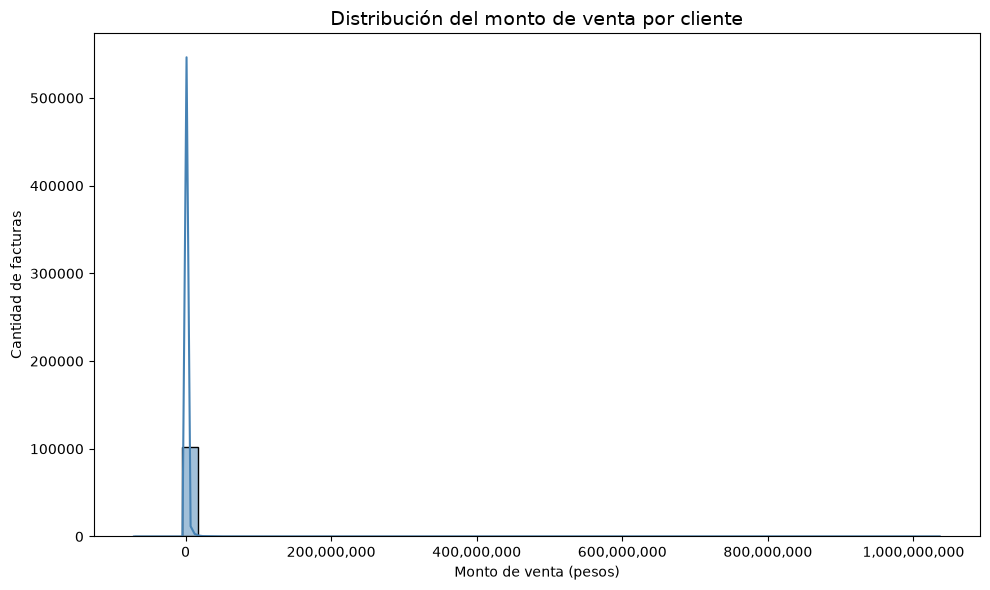

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=clientes,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=ax
)
ax.set_title('Distribución del monto de venta por cliente', fontsize=14)
ax.set_xlabel('Monto de venta (pesos)')
ax.set_ylabel('Cantidad de facturas')
#ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

> ***The data is skewed to the the right, so in this ocassion we are going to apply a log scale (I have done some researchs to look for it)***

In [6]:
devoluciones = clientes[clientes['montoventapesos']<=0]
clientes_positivos = clientes[(clientes['montoventapesos']>0)&(clientes['margen']>0)]


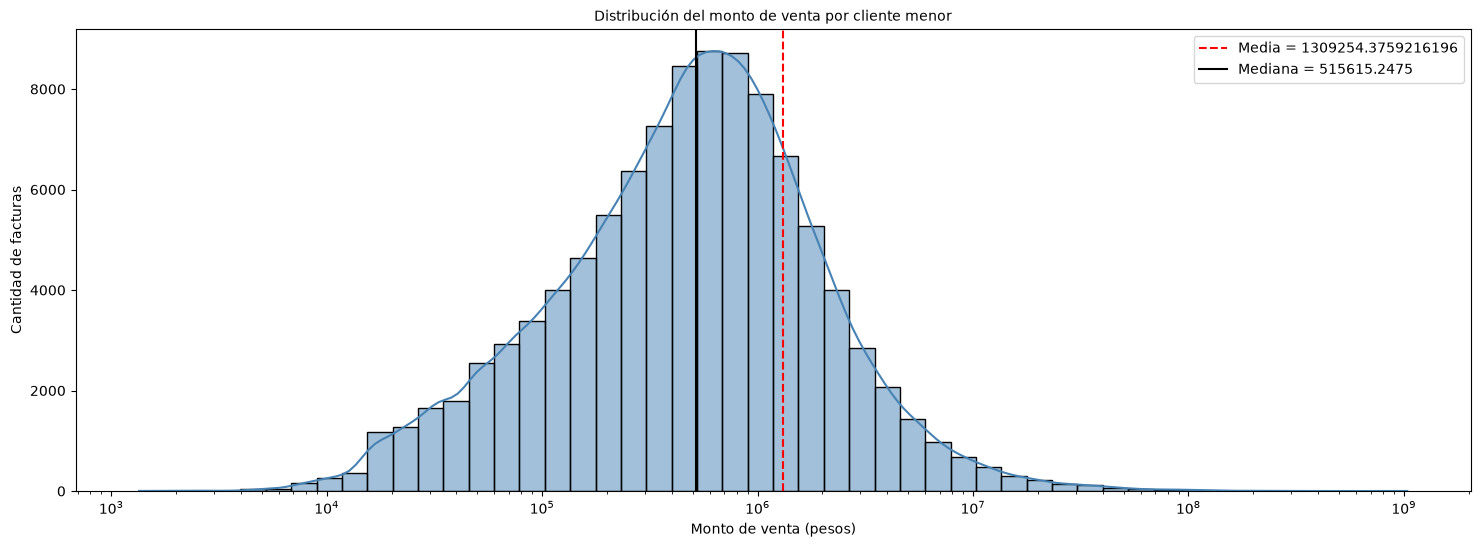

In [7]:
fig, axes = plt.subplots(figsize=(18, 6))
sns.histplot(
    data=clientes_positivos,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=axes,
    log_scale=True
)

media = clientes_positivos['montoventapesos'].mean()
median = clientes_positivos['montoventapesos'].median() 
axes.set_title('Distribución del monto de venta por cliente menor', fontsize=10)
axes.set_xlabel('Monto de venta (pesos)')
axes.set_ylabel('Cantidad de facturas')
axes.axvline(media,label=f'Media = {media}', color= 'red',linestyle='--')
axes.axvline(median,label=f'Mediana = {median}', color= 'black',linestyle='-')
#axes[0].ticklabel_format(style='plain', axis='x')
#axes.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes.legend()

# **Machine Learning**
---

## Escalar los datos

In [ ]:
from sklearn.preprocessing import QuantileTransformer

variables = ['frecuencia','recencia','montoventapesos']


x = clientes_positivos[variables].values
x_scaled = QuantileTransformer(output_distribution='normal', random_state=42).fit_transform(x)

x_scaled[:,0] = x_scaled[:,0]*5
x_scaled[:,1] = x_scaled[:,1]*4
x_scaled[:,2] = x_scaled[:,2]*3
 


> Take into account the a ***log10*** for 0 y ***-inf*** so it gives and error

In [25]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)

clientes_positivos['pca1'] = x_pca[:,0]
clientes_positivos['pca2'] = x_pca[:,1]


pd.DataFrame(
    data=pca.components_,
    columns=variables,
    index=['PCA1','PCA2']
)




,frecuencia,recencia,montoventapesos
PCA1,0.92,-0.29,0.27
PCA2,0.31,0.95,-0.06


<Axes: xlabel='pca1', ylabel='pca2'>

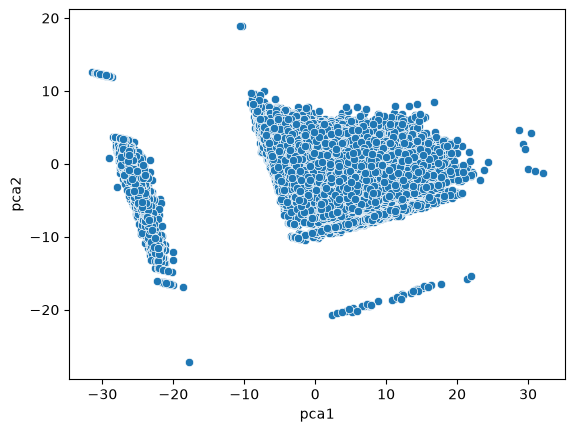

In [26]:
plt.Figure(figsize=(10,14))
sns.scatterplot(
    data=clientes_positivos,
    x=clientes_positivos['pca1'],
    y=clientes_positivos['pca2']
)

## ***Clustering***

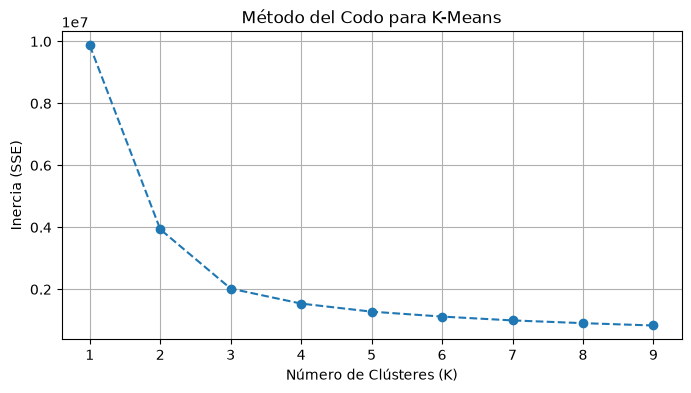

In [38]:
from sklearn.cluster import KMeans

inertia = []
rango = range(1,10)

valores = x_scaled
for i in rango:
    k_means = KMeans(n_clusters=i,random_state=42, n_init=10)
    k_means.fit(valores)
    inertia.append(k_means.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(rango, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (SSE)')
plt.title('Método del Codo para K-Means')
plt.grid(True)
plt.show()


> Para este tema use un **K_optimo = 3**

In [28]:
K_means= KMeans(n_clusters=4,random_state=42, n_init=1000).fit(valores)

datos = K_means.transform(valores)
print(K_means.cluster_centers_)
clientes_positivos['cluster'] = K_means.labels_

[[  6.35310569  -3.44875887   3.24641715]
 [ -3.53062816   3.32522859  -2.08503744]
 [-25.99668791   4.8949588   -4.98228531]
 [  0.52779846  -1.26200364   0.52090035]]


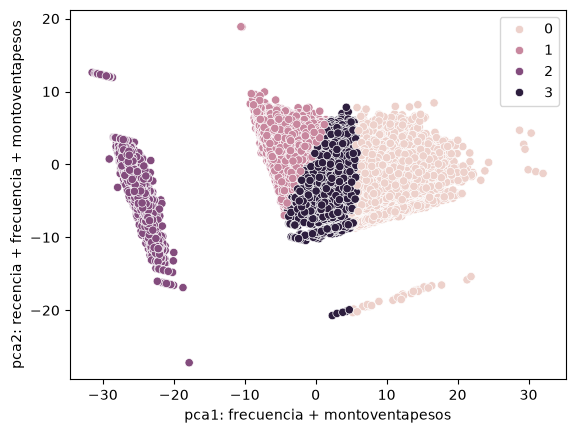

In [ ]:
plt.Figure(figsize=(10,14))

sns.scatterplot(
    data=clientes_positivos,
    x='pca1',
    y='pca2',
    hue= 'cluster'
)

plt.xlabel('pca1: frecuencia + montoventapesos')
plt.ylabel('pca2: recencia')
plt.legend(loc = 'upper right')


## **Merging clusters with the client historial and setting names of each one**

### ***Clusters Analysis***

This next step we start an analysis to see what are the features of each cluster to categorize them propertly 

#### ***Setting name of the clusters***

C:\Users\keyne\AppData\Local\Temp\ipykernel_33800\4192310848.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\keyne\AppData\Local\Temp\ipykernel_33800\4192310848.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\keyne\AppData\Local\Temp\ipykernel_33800\4192310848.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\keyne\AppData\Local\Temp\ipykernel_33800\4192310848.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

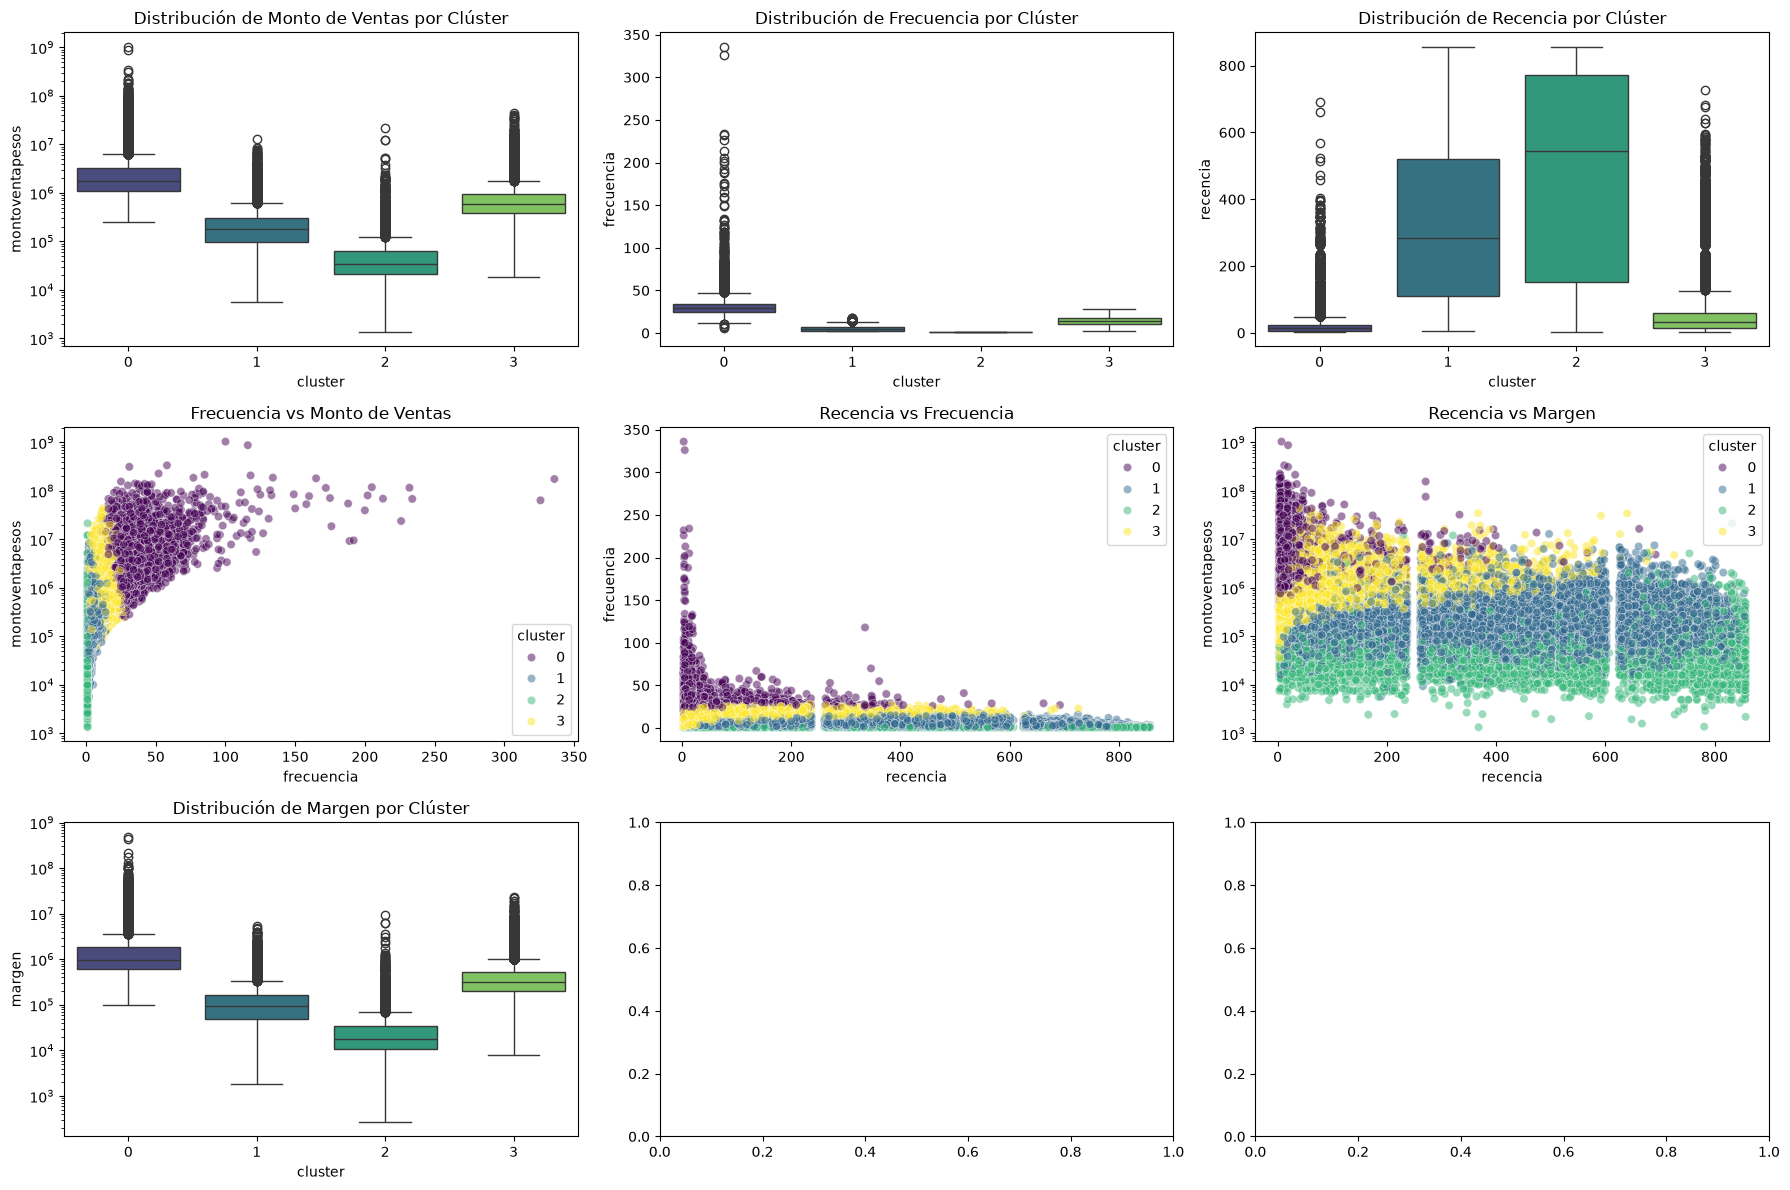

In [30]:
import matplotlib.ticker as ticker

# Crear una figura con múltiples subplots para analizar las dimensiones RFM por clúster
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))

# 1. Boxplot de Monto de Ventas por Clúster
sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='montoventapesos', 
    ax=axes[0, 0], 
    palette='viridis'
)
axes[0, 0].set_title('Distribución de Monto de Ventas por Clúster')
axes[0, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[0,0].set_yscale('log')

# 2. Boxplot de Frecuencia por Clúster
sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='frecuencia', 
    ax=axes[0, 1], 
    palette='viridis'
)
axes[0, 1].set_title('Distribución de Frecuencia por Clúster')

# 3. Boxplot de Recencia por Clúster
sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='recencia', 
    ax=axes[0, 2], 
    palette='viridis'
)
axes[0, 2].set_title('Distribución de Recencia por Clúster')

# 4. Scatter Plot: Frecuencia vs Monto de Ventas
sns.scatterplot(
    data=clientes_positivos, 
    x='frecuencia', 
    y='montoventapesos', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 0], 
    alpha=0.5
)
axes[1, 0].set_title('Frecuencia vs Monto de Ventas')
axes[1, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[1, 0].set_yscale('log')

# 5. Scatter Plot: Recencia vs Frecuencia
sns.scatterplot(
    data=clientes_positivos, 
    x='recencia', 
    y='frecuencia', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 1], 
    alpha=0.5
)
axes[1, 1].set_title('Recencia vs Frecuencia')

# 6. Scatter Plot: Recencia vs Monto de Ventas
sns.scatterplot(
    data=clientes_positivos, 
    x='recencia', 
    y='montoventapesos', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 2], 
    alpha=0.5
)
axes[1, 2].set_title('Recencia vs Margen')
axes[1, 2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[1, 2].set_yscale('log')

sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='margen', 
    ax=axes[2,0], 
    palette='viridis'
)
axes[2,0].set_title('Distribución de Margen por Clúster')
axes[2,0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[2,0].set_yscale('log')

plt.tight_layout()
plt.show()

C:\Users\keyne\AppData\Local\Temp\ipykernel_33800\2841566347.py:1: UserWarning: Ignoring `ax`; jointplot is a figure-level function.
  sns.jointplot(


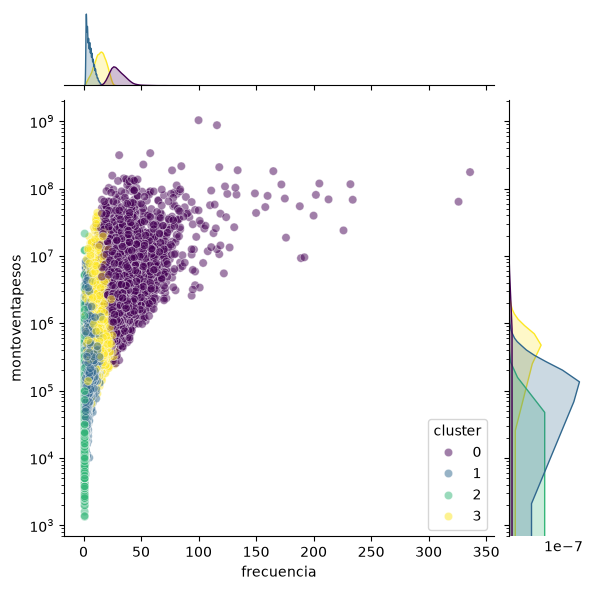

In [31]:
sns.jointplot(
    data=clientes_positivos, 
    x='frecuencia', 
    y='montoventapesos', 
    hue='cluster', 
    kind='scatter',
    palette='viridis', 
    ax=axes[1, 0], 
    alpha=0.5
)
plt.yscale('log')


In [32]:
def auto_nombrar_clusters(df_input):
    """We are using quantiles to categorize the clusters names here"""
    
    df = df_input.copy()

   
    p_rec_baja = df["recencia"].quantile(0.33) 
    p_rec_alta = df["recencia"].quantile(0.66)

    p_frec_alta = df["frecuencia"].quantile(0.75)
    p_frec_media = df["frecuencia"].quantile(0.40)

    p_monto_alto = df["montoventapesos"].quantile(0.75)
    p_monto_bajo = df["montoventapesos"].quantile(0.25)

    # Condition
    def asignar_etiqueta(row):
        rec = row["recencia"]
        frec = row["frecuencia"]
        monto = row["montoventapesos"]

        # Vip_clients
        if rec <= p_rec_baja and frec >= p_frec_alta and monto >= p_monto_alto:
            return "Champion VIP"

        elif rec <= p_rec_alta and frec >= p_frec_media:
            return "Loyal Clients"
        
        elif rec <= p_rec_baja and frec < p_frec_media:
            return "Promising / Recents"

        elif rec > p_rec_alta and frec >= p_frec_media:
            return "In Risk / To recover"
       
        elif rec > p_rec_alta and frec < p_frec_media:
            return "Inactives / Churn"

        else:
            return "Once in a while"

    # Applying the function
    df["nombre_cluster"] = df.apply(asignar_etiqueta, axis=1)

    return df


# Reasinging the dataframe
clientes_positivos = auto_nombrar_clusters(clientes_positivos)

### ***Merging with the client history***

In [33]:
df_clientes = pd.merge(clientes_positivos[['cliente','cluster','nombre_cluster']],df, left_on='cliente', right_on='cliente', how='inner')

### ***Clients understanding***

I visualized every cluster with his own different color to see how they behave inside the clusters,and I found that they share the features that I actually want them to have.
As we can see the company has a very close group of clients which overlap specially on recency and frecuency but with a different purchase, and that is when this analysis takes action, in recognizing those clients that are different specially on the ***purchase***, 


In [34]:
df_clientes.to_csv(f'{base_dir}/files/segmentos.csv')

In [35]:
clientes_positivos[(clientes_positivos['cluster']==0)].describe()

,montoventapesos,frecuencia,recencia,margen,pca1,pca2,cluster
count,"25,133.00","25,133.00","25,133.00","25,133.00","25,133.00","25,133.00","25,133.00"
mean,"3,636,069.34",30.07,20.84,"2,034,831.73",8.98,-1.08,0.00
std,"11,854,022.55",9.81,29.36,"6,183,498.19",2.67,2.68,0.00
min,"254,507.63",6.00,2.00,"100,634.47",4.64,-20.32,0.00
25%,"1,120,793.81",25.00,7.00,"597,623.66",6.88,-2.70,0.00
50%,"1,765,345.05",29.00,14.00,"968,637.29",8.40,-0.73,0.00
75%,"3,202,690.29",34.00,24.00,"1,821,934.25",10.46,0.75,0.00
max,"1,036,088,953.70",336.00,692.00,"491,067,982.92",32.05,8.44,0.00


In [37]:
resumen_clusters = clientes_positivos.groupby(['cluster','nombre_cluster']).agg(
    num_clientes = ('cliente', 'count'),
    recencia_min = ('recencia', 'min'),
    recencia_max = ('recencia', 'max'),
    recencia_median = ('recencia', 'median'),
    recencia_avg = ('recencia', 'mean'),
    frecuencia_min = ('frecuencia', 'min'),
    frecuencia_max = ('frecuencia', 'max'),
    frecuencia_median = ('frecuencia', 'median'),
    frecuencia_avg = ('frecuencia', 'mean'),
    monto_min = ('montoventapesos', 'min'),
    monto_max = ('montoventapesos', 'max'),
    monto_median = ('montoventapesos', 'median'),
    monto_avg = ('montoventapesos', 'mean'),
    margen_min = ('margen', 'min'),
    margen_max = ('margen', 'max'),
    margen_median = ('margen', 'median'),
    margen_avg = ('margen', 'mean')
).reset_index()

resumen_clusters

,cluster,nombre_cluster,num_clientes,recencia_min,recencia_max,recencia_median,recencia_avg,frecuencia_min,frecuencia_max,frecuencia_median,frecuencia_avg,monto_min,monto_max,monto_median,monto_avg,margen_min,margen_max,margen_median,margen_avg
0,0,Champion VIP,12477,2,20,12.00,11.52,21,336,32.00,33.17,"1,170,492.68","1,036,088,953.70","2,381,483.44","4,970,006.65","236,878.59","491,067,982.92","1,330,496.92","2,793,493.68"
1,0,In Risk / To recover,435,102,692,173.00,191.64,18,118,28.00,30.25,"521,006.32","155,754,642.27","2,488,835.20","4,823,340.24","242,175.99","71,851,726.80","1,386,628.96","2,677,827.80"
2,0,Loyal Clients,12218,2,101,20.00,24.29,11,85,26.00,26.91,"254,507.63","215,137,832.73","1,110,323.53","2,232,218.28","100,634.47","127,531,604.87","598,834.36","1,237,552.51"
3,0,Promising / Recents,3,2,2,2.00,2.00,6,8,7.00,7.00,"378,382.44","1,560,155.59","1,223,331.24","1,053,956.43","230,118.31","864,779.85","638,514.72","577,804.29"
4,1,In Risk / To recover,4583,102,796,306.00,324.09,9,18,10.00,10.80,"76,052.23","7,549,127.22","374,162.96","455,311.31","18,732.55","3,678,724.52","197,325.22","243,847.73"
5,1,Inactives / Churn,18416,102,857,411.00,424.06,2,8,4.00,4.35,"5,714.29","12,958,603.26","144,796.05","237,464.63","1,798.41","5,292,718.74","75,593.98","128,109.43"
6,1,Loyal Clients,544,47,101,82.00,81.03,9,12,9.00,9.56,"97,437.02","551,512.53","241,147.64","253,677.94","43,455.67","385,877.87","126,672.92","133,680.22"
7,1,Once in a while,5710,23,101,59.00,59.57,2,8,4.00,4.55,"13,025.21","2,893,391.26","162,092.53","209,347.36","4,713.92","1,627,302.74","86,342.07","114,523.08"
8,1,Promising / Recents,601,5,20,18.00,16.60,2,5,2.00,2.56,"16,134.45","705,936.38","94,117.72","111,791.52","2,530.98","421,864.42","49,616.72","61,810.89"
9,2,Inactives / Churn,6736,102,857,667.00,582.50,1,1,1.00,1.00,"1,344.54","21,484,578.90","31,932.80","75,596.90",266.24,"9,154,297.06","16,386.32","40,816.50"
